# Experiment 1: Sugar GRN Activation - Frequency Sweep

**Purpose**
- Reproduce Shiu et al. (2024) Figure 1c-d
- Test neural response across 20 activation frequencies (10-200 Hz)
- Validate against original paper results
- Generate Top 200 responsive neurons for Exp2/3

**Validation & Controls**
- Correlation with Shiu et al. (2024) results (r > 0.85 expected)
- ID version conversion (v630 → v783) with verification
- Shuffled connectivity control (proves model depends on true connectome)
- Multi-motor neuron analysis (MN6, 8, 9, 11 responses)

**Configuration**
- Neurons: 21 Sugar GRNs (left hemisphere, v783)
- Frequencies: 10, 20, ..., 200 Hz (20 frequencies)
- Trials: 10 per frequency
- Batches: 4 batches × 5 frequencies (for memory management)
- Workers: 4 (6-core machine)

**Expected Runtime**
- Per batch: ~15-20 minutes
- Total: ~1.5 hours (can run overnight)

**Outputs**
- `results/exp1_sugar_activation/exp1_complete_results.pkl`
- `results/exp1_sugar_activation/top_200_neurons.npy` (for Exp2/3)
- `results/exp1_sugar_activation/figures/` (6 plots)
  - Correlation with original paper
  - Network-wide response heatmap
  - Proboscis motor neurons (MN6, 8, 9, 11)
  - Summary statistics
  - Shuffled connectivity control
---

## 1. Environment Setup

In [2]:
import numpy as np
import pandas as pd
import sys
from pathlib import Path

from time import time
import pickle

import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import seaborn as sns

from brian2 import Hz, ms, start_scope, volt

from joblib import Parallel, delayed
import gc

print("✅ Standard libraries imported")

✅ Standard libraries imported


In [3]:
# FlyWire tools
import pyarrow.parquet as pq
from caveclient import CAVEclient

print("Initializing CAVEclient...")
client = CAVEclient('flywire_fafb_public')
print("✅ Connected to FlyWire")

Initializing CAVEclient...
✅ Connected to FlyWire


In [4]:
# FlyLIF modules
from flylif.core.parameters import DEFAULT_PARAMS
from flylif.core.data_loader import load_simulation_data
from flylif.core.network import build_network
from flylif.core.simulation import run_simulation
from flylif.core.experiments import run_exp1_batch,shuffled_control_worker
from flylif.utils.visualization import plot_correlation, plot_response_heatmap, plot_frequency_response_curve, plot_summary_statistics
from flylif.utils.cave_utils import convert_neuron_list_cached
from flylif.utils.checkpoint import CheckpointManager
from flylif.utils.memory_utils import print_memory, check_memory_safe, memory_cleanup, MemoryMonitor

print("✅ FlyLIF modules imported")

✅ FlyLIF modules imported


In [5]:
# Auto-reload for development
%load_ext autoreload
%autoreload 2
print("✅ Auto-reload enabled")

✅ Auto-reload enabled


## 2. Configuration

In [6]:
# ===== Configuration =====
# Project root (notebooks are in root directory)
PROJECT_ROOT = Path.cwd()  

CONFIG = {
    'data_dir': PROJECT_ROOT / 'data_783',
    'connections_file': 'proofread_connections_783.feather',
    'root_ids_file': 'proofread_root_ids_783.npy',
}

# Exp1 specific directories
CACHE_DIR = PROJECT_ROOT / 'cache' / 'id_conversions'
CHECKPOINT_DIR = PROJECT_ROOT / 'checkpoints' / 'exp1'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'exp1_sugar_activation'
FIGURES_DIR = RESULTS_DIR / 'figures'
ORIG_PAPER_DATA = PROJECT_ROOT / 'reference_data' / 'sugarR_100Hz.parquet'

# Create directories
CACHE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration:")
print(f"  Project root: {PROJECT_ROOT}")
print(f"  Data: {CONFIG['data_dir']}")
print(f"  Results: {RESULTS_DIR}")

Configuration:
  Project root: /Users/ruiluo/MyLibrary/connectome/LIFmodel/LIF_simulation
  Data: /Users/ruiluo/MyLibrary/connectome/LIFmodel/LIF_simulation/data_783
  Results: /Users/ruiluo/MyLibrary/connectome/LIFmodel/LIF_simulation/results/exp1_sugar_activation


## 3. Define Neuron IDs

### 3.1 Original v630 IDs

In [7]:
print("=" * 70)
print("Defining Original Paper Neuron IDs (v630)")
print("=" * 70)

# Original paper neurons (from Shiu et al., FlyWire v630)
NEU_SUGAR_v630 = [
    720575940624963786, 720575940630233916, 720575940637568838, 720575940638202345, 720575940617000768,
    720575940630797113, 720575940632889389, 720575940621754367, 720575940621502051, 720575940640649691,
    720575940639332736, 720575940616885538, 720575940639198653, 720575940620900446, 720575940617937543,
    720575940632425919, 720575940633143833, 720575940612670570, 720575940628853239, 720575940629176663,
    720575940611875570
]

NEU_MN9_v630 = [720575940660219265]  # MN9 right (contralateral)
NEU_MN9_LEFT_v630 = [720575940645521262]  # MN9 left (ipsilateral)

print(f"\nOriginal neuron counts:")
print(f"  Sugar GRNs: {len(NEU_SUGAR_v630)}")
print(f"  MN9 Right: {len(NEU_MN9_v630)}")
print(f"  MN9 Left: {len(NEU_MN9_LEFT_v630)}")

Defining Original Paper Neuron IDs (v630)

Original neuron counts:
  Sugar GRNs: 21
  MN9 Right: 1
  MN9 Left: 1


### 3.2 Convert to v783

In [7]:
print("\n" + "=" * 70)
print("Converting Neuron IDs (v630 → v783)")
print("=" * 70)
print("⚠️  This uses FlyWire API, will be cached to avoid repeated calls\n")

# Convert Sugar GRNs
NEU_SUGAR_LEFT = convert_neuron_list_cached(
    old_list=NEU_SUGAR_v630,
    cache_file=CACHE_DIR / 'sugar_grns_v630_to_v783.pkl',
    new_ver=783,
    force_update=False,
    verbose=True
)

# Convert MN9
NEU_MN9_RIGHT = convert_neuron_list_cached(
    old_list=NEU_MN9_v630,
    cache_file=CACHE_DIR / 'mn9_v630_to_v783.pkl',
    new_ver=783,
    verbose=True
)

NEU_MN9_LEFT = convert_neuron_list_cached(
    old_list=NEU_MN9_LEFT_v630,
    cache_file=CACHE_DIR / 'mn9_left_v630_to_v783.pkl',
    new_ver=783,
    verbose=True
)

print(f"\n   Sugar GRNs (v783): {len(NEU_SUGAR_LEFT)}")
print(f"   MN9 Right: {NEU_MN9_RIGHT[0]}")
print(f"   MN9 Left: {NEU_MN9_LEFT[0]}")


Converting Neuron IDs (v630 → v783)
⚠️  This uses FlyWire API, will be cached to avoid repeated calls

Loading cached ID conversion from /Users/ruiluo/MyLibrary/connectome/LIFmodel/LIF_simulation/cache/id_conversions/sugar_grns_v630_to_v783.pkl
  ✅ Using cached conversion (21 IDs)
Loading cached ID conversion from /Users/ruiluo/MyLibrary/connectome/LIFmodel/LIF_simulation/cache/id_conversions/mn9_v630_to_v783.pkl
  ✅ Using cached conversion (1 IDs)
Loading cached ID conversion from /Users/ruiluo/MyLibrary/connectome/LIFmodel/LIF_simulation/cache/id_conversions/mn9_left_v630_to_v783.pkl
  ✅ Using cached conversion (1 IDs)

   Sugar GRNs (v783): 21
   MN9 Right: 720575940660219265
   MN9 Left: 720575940618238523


## 4. Load Data

In [8]:
print("\n" + "=" * 70)
print("Loading Optimized Connectivity Data")
print("=" * 70)

print_memory("Before loading: ")

t0 = time()
DATA = load_simulation_data(CONFIG)

print(f"\n✅ Loaded in {time()-t0:.1f}s")
print(f"   Data size: {DATA['df_conn'].memory_usage(deep=True).sum()/1e6:.0f} MB")
print(f"   Neurons: {DATA['n_neurons']:,}")
print(f"   Connections: {len(DATA['df_conn']):,}")

print_memory("After loading: ")


Loading Optimized Connectivity Data
Before loading: Memory: 36.7% used, 10.9GB free, Swap: 0.0GB
Loading Data (Simulation Mode - Optimized)

[1/5] Loading root IDs...
   Neurons: 139,255

[2/5] Creating mappings...
   ✅ Done

[3/5] Loading connectivity...
   Total rows: 16,847,997
   Loading... 100.0%

[4/5] Computing neuron signs...
   Computing neuron signs...
   Excitatory: 10,020,094, Inhibitory: 6,827,903 (0.4s)

[5/5] Optimizing data...
   Identified columns: pre=pre_pt_root_id, post=post_pt_root_id, weight=syn_count
   Filtering syn_count >= 5...
   16,847,997 -> 2,710,038 (16.1%)
   Creating optimized DataFrame (4 columns only)...

[Summary]
   Rows: 2,710,038
   Columns: ['pre_pt_root_id', 'post_pt_root_id', 'syn_count', 'neuron_sign']
   Memory: 68 MB
   Reduction: 97.0%

✅ Loaded in 23.2s
   Data size: 68 MB
   Neurons: 139,255
   Connections: 2,710,038
After loading: Memory: 44.3% used, 9.6GB free, Swap: 0.0GB


{'used_gb': 7.604711424,
 'available_gb': 9.571680256,
 'percent': 44.3,
 'swap_gb': 0.0}

## 5. Batch Configuration

In [9]:
# Define 4 batches, 5 frequencies each
BATCH_CONFIG = {
    'batch1': [10, 20, 30, 40, 50],
    'batch2': [60, 70, 80, 90, 100],
    'batch3': [110, 120, 130, 140, 150],
    'batch4': [160, 170, 180, 190, 200],
}

print("Batch configuration:")
for name, freqs in BATCH_CONFIG.items():
    print(f"  {name}: {freqs}")

print(f"\nTotal frequencies: {sum(len(f) for f in BATCH_CONFIG.values())}")

Batch configuration:
  batch1: [10, 20, 30, 40, 50]
  batch2: [60, 70, 80, 90, 100]
  batch3: [110, 120, 130, 140, 150]
  batch4: [160, 170, 180, 190, 200]

Total frequencies: 20


## 6. Execute Batches

**Instructions**: Run each batch cell separately. Can restart kernel between batches if needed.

⚠️ If kernel restarted, re-run Sections 1-5 first!

### 6.1 Batch 1 (10-50 Hz)

In [10]:
results_batch1 = run_exp1_batch(
    freq_list=BATCH_CONFIG['batch1'],
    batch_name='Batch 1',
    n_workers=4,
    n_trials=10
)

print("\n✅ Batch 1 complete!")


Batch: Batch 1
✅ All frequencies already completed, loading from checkpoint...

✅ Batch 1 complete!


### 6.2 Batch 2 (60-100 Hz)

In [11]:
results_batch2 = run_exp1_batch(
    freq_list=BATCH_CONFIG['batch2'],
    batch_name='Batch 2',
    n_workers=4,
    n_trials=10
)

print("\n✅ Batch 2 complete!")


Batch: Batch 2
✅ All frequencies already completed, loading from checkpoint...

✅ Batch 2 complete!


### 6.3 Batch 3 (110-150 Hz)

In [12]:
results_batch3 = run_exp1_batch(
    freq_list=BATCH_CONFIG['batch3'],
    batch_name='Batch 3',
    n_workers=4,
    n_trials=10
)

print("\n✅ Batch 3 complete!")


Batch: Batch 3
✅ All frequencies already completed, loading from checkpoint...

✅ Batch 3 complete!


### 6.4 Batch 4 (160-200 Hz)

In [13]:
results_batch4 = run_exp1_batch(
    freq_list=BATCH_CONFIG['batch4'],
    batch_name='Batch 4 (Final)',
    n_workers=4,
    n_trials=10
)

print("\n✅ Batch 4 complete!")
print("\nNext: Run Cell 8 (Merge all batches)")


Batch: Batch 4 (Final)
✅ All frequencies already completed, loading from checkpoint...

✅ Batch 4 complete!

Next: Run Cell 8 (Merge all batches)


## 7. Process Results

### 7.1 Merge batches from checkpoint

In [14]:
print("\n" + "=" * 70)
print("Merging All Batches")
print("=" * 70)

# Load from checkpoint (in case kernel was restarted)
ckpt = CheckpointManager('./checkpoints/exp1')
all_results = ckpt.load_all_completed()

print(f"\n✅ Loaded {len(all_results)} frequencies from checkpoint")

# Organize results
results_dict = all_results

# Create summary
summary = []
for freq in sorted(all_results.keys()):
    res = all_results[freq]
    summary.append({
        'Frequency': freq,
        'Active Neurons': res['n_active'],
        'Total Spikes': res['n_spikes'],
    })

df_summary = pd.DataFrame(summary)

print(f"\nSummary:")
print(df_summary.to_string(index=False))


Merging All Batches

✅ Loaded 20 frequencies from checkpoint

Summary:
 Frequency  Active Neurons  Total Spikes
        10              36          2437
        20              51          5913
        30              82         10230
        40             215         16749
        50             326         28073
        60             319         46499
        70             329         60793
        80             343         74934
        90             352         85374
       100             350         96789
       110             359        106794
       120             371        114943
       130             363        121636
       140             365        128508
       150             369        136287
       160             390        142066
       170             379        148738
       180             373        152942
       190             381        158516
       200             388        166009


### 7.2. Calculate Firing Rates

In [15]:
print("\n" + "=" * 70)
print("Calculating Firing Rates")
print("=" * 70)

# Extract firing rates for all neurons
all_firing_rates = {}
duration_s = float(DEFAULT_PARAMS['t_run'] / ms) / 1000

for freq, res in results_dict.items():
    df = res['df']
    if len(df) > 0:
        spike_counts = df.groupby('flywire_id').size()
        firing_rates = spike_counts / (10 * duration_s)  # 10 trials
        all_firing_rates[freq] = firing_rates.to_dict()
    else:
        all_firing_rates[freq] = {}

print(f"✅ Processed {len(all_firing_rates)} frequencies")

# Check maximum firing rate across all frequencies
print(f"\nFiring rate statistics:")
for freq in sorted(all_firing_rates.keys()):
    rates = list(all_firing_rates[freq].values())
    if rates:
        print(f"  {freq:3d} Hz: max={max(rates):6.1f} Hz, active neurons={len(rates)}")
    else:
        print(f"  {freq:3d} Hz: No activity")


Calculating Firing Rates
✅ Processed 20 frequencies

Firing rate statistics:
   10 Hz: max=  12.2 Hz, active neurons=36
   20 Hz: max=  34.1 Hz, active neurons=51
   30 Hz: max=  50.8 Hz, active neurons=82
   40 Hz: max=  64.6 Hz, active neurons=215
   50 Hz: max=  75.2 Hz, active neurons=326
   60 Hz: max=  87.8 Hz, active neurons=319
   70 Hz: max=  94.2 Hz, active neurons=329
   80 Hz: max= 100.6 Hz, active neurons=343
   90 Hz: max= 107.6 Hz, active neurons=352
  100 Hz: max= 113.8 Hz, active neurons=350
  110 Hz: max= 118.9 Hz, active neurons=359
  120 Hz: max= 125.4 Hz, active neurons=371
  130 Hz: max= 133.9 Hz, active neurons=363
  140 Hz: max= 147.2 Hz, active neurons=365
  150 Hz: max= 156.1 Hz, active neurons=369
  160 Hz: max= 166.4 Hz, active neurons=390
  170 Hz: max= 174.0 Hz, active neurons=379
  180 Hz: max= 187.0 Hz, active neurons=373
  190 Hz: max= 194.8 Hz, active neurons=381
  200 Hz: max= 204.1 Hz, active neurons=388


## 8. Validation: Comparison with Original Paper

This section compares our results with Shiu et al. (2024) at 100Hz.

### 8.1 Load original data

In [16]:
print("\n" + "=" * 70)
print("Loading Original Paper Results (v630, 100Hz)")
print("=" * 70)

# Use path defined in Section 2
orig_data_path = ORIG_PAPER_DATA

if not orig_data_path.exists():
    print(f"\n⚠️  Original paper data not found (optional)")
    print(f"   Expected: {orig_data_path}")
    print(f"   This is optional - validation will be skipped")
    print(f"   Experiments are still valid without this file")
    has_original = False
else:
    print(f"\nLoading: {orig_data_path}")
    
    pf = pq.ParquetFile(orig_data_path)
    df_orig_v630 = pd.DataFrame({
        'flywire_id': pf.read(['flywire_id']).column('flywire_id').to_pylist(),
    })
    
    # Calculate original firing rates (v630 IDs)
    spike_counts_v630 = df_orig_v630.groupby('flywire_id').size()
    rate_orig_v630 = spike_counts_v630 / 30.0  # 30 trials in original
    rate_orig_v630.name = 'Original_v630'
    
    # Our results (v783 IDs)
    rate_ours_v783 = pd.Series(all_firing_rates[100], name='Ours_v783')
    
    print(f"   ✅ Loaded")
    print(f"      Original (v630): {len(rate_orig_v630)} active neurons")
    print(f"      Ours (v783):     {(rate_ours_v783>0).sum()} active neurons")
    
    has_original = True


Loading Original Paper Results (v630, 100Hz)

Loading: /Users/ruiluo/MyLibrary/connectome/LIFmodel/LIF_simulation/reference_data/sugarR_100Hz.parquet
   ✅ Loaded
      Original (v630): 404 active neurons
      Ours (v783):     350 active neurons


### 8.2 Identify ID discrepancies

In [17]:
if has_original:
    print("\n" + "=" * 70)
    print("Analyzing ID Discrepancies")
    print("=" * 70)
    
    # Find discrepancies
    ids_only_orig = set(rate_orig_v630.index) - set(rate_ours_v783.index)
    ids_only_ours = set(rate_ours_v783[rate_ours_v783>0].index) - set(rate_orig_v630.index)
    
    print(f"\n  Only in original (v630): {len(ids_only_orig)} neurons")
    print(f"  Only in ours (v783):     {len(ids_only_ours)} neurons")
    
    # Common neurons with large firing rate differences
    common_ids = set(rate_orig_v630.index) & set(rate_ours_v783.index)
    df_common = pd.DataFrame({
        'orig': rate_orig_v630[list(common_ids)],
        'ours': rate_ours_v783[list(common_ids)]
    }).fillna(0)
    
    # Active in both
    active_both = (df_common['orig'] > 0) & (df_common['ours'] > 0)
    df_active_common = df_common[active_both].copy()
    df_active_common['abs_diff'] = np.abs(df_active_common['orig'] - df_active_common['ours'])
    
    # Large difference (>20 Hz or >50% relative)
    large_diff_mask = (df_active_common['abs_diff'] > 20) | \
                      (df_active_common['abs_diff'] / df_active_common['orig'] > 0.5)
    ids_large_diff = df_active_common[large_diff_mask].index.tolist()
    
    print(f"  Large differences: {len(ids_large_diff)} neurons (>20Hz or >50%)")
    
    # Combine all discrepancy types
    ids_need_conversion = list(ids_only_orig) + ids_large_diff
    
    print(f"\n[Summary]")
    print(f"  Total IDs to convert: {len(ids_need_conversion)}")
    print(f"  Breakdown:")
    print(f"    - Missing from our data: {len(ids_only_orig)}")
    print(f"    - Large firing rate diff: {len(ids_large_diff)}")
    
    # Show examples
    if ids_only_orig:
        print(f"\n  Examples (missing IDs): {list(ids_only_orig)[:5]}")
    
    if ids_large_diff:
        top_diff = df_active_common.nlargest(5, 'abs_diff')
        print(f"\n  Top 5 firing rate discrepancies:")
        for idx, row in top_diff.iterrows():
            print(f"    {idx}: orig={row['orig']:.1f}, ours={row['ours']:.1f}, diff={row['abs_diff']:.1f}")


Analyzing ID Discrepancies

  Only in original (v630): 100 neurons
  Only in ours (v783):     46 neurons
  Large differences: 144 neurons (>20Hz or >50%)

[Summary]
  Total IDs to convert: 244
  Breakdown:
    - Missing from our data: 100
    - Large firing rate diff: 144

  Examples (missing IDs): [720575940629664768, 720575940626478082, 720575940609016843, 720575940615052812, 720575940620271636]

  Top 5 firing rate discrepancies:
    720575940610001220: orig=5.0, ours=53.4, diff=48.4
    720575940625175054: orig=48.6, ours=12.8, diff=35.8
    720575940618165019: orig=86.9, ours=51.2, diff=35.7
    720575940629778554: orig=76.1, ours=41.7, diff=34.4
    720575940630868793: orig=84.2, ours=50.1, diff=34.1


### 8.3 Convert discrepancy IDs

In [18]:
if has_original and 'ids_need_conversion' in dir() and len(ids_need_conversion) > 0:
    print("\n" + "=" * 70)
    print(f"Converting {len(ids_need_conversion)} Discrepancy IDs (v630 → v783)")
    print("=" * 70)
    
    cache_file_disc = CACHE_DIR / 'discrepancy_ids_v630_to_v783.pkl'
    
    t0 = time()
    
    ids_converted_v783 = convert_neuron_list_cached(
        old_list=ids_need_conversion,
        cache_file=cache_file_disc,
        new_ver=783,
        verbose=True
    )
    
    conversion_time = time() - t0
    
    print(f"\n✅ Conversion complete in {conversion_time:.1f}s")
    
    # Create mapping (v630 → v783)
    id_mapping = {old: new for old, new in zip(ids_need_conversion, ids_converted_v783)}
    
    # Check how many actually changed
    n_changed = sum(1 for old, new in id_mapping.items() if old != new)
    n_unchanged = len(id_mapping) - n_changed
    
    print(f"\n  ID changes: {n_changed} changed, {n_unchanged} unchanged")
    
    if n_changed > 0:
        print(f"\n  Changed examples (first 5):")
        count = 0
        for old, new in id_mapping.items():
            if old != new and count < 5:
                print(f"    {old} → {new}")
                count += 1
else:
    print("\n⚠️  No discrepancies to convert (or no original data)")
    id_mapping = {}


Converting 244 Discrepancy IDs (v630 → v783)
Loading cached ID conversion from /Users/ruiluo/MyLibrary/connectome/LIFmodel/LIF_simulation/cache/id_conversions/discrepancy_ids_v630_to_v783.pkl
  ✅ Using cached conversion (244 IDs)

✅ Conversion complete in 0.0s

  ID changes: 48 changed, 196 unchanged

  Changed examples (first 5):
    720575940629664768 → 720575940635837887
    720575940626478082 → 720575940619898526
    720575940609016843 → 720575940629459718
    720575940620282900 → 720575940643112333
    720575940617588258 → 720575940642449909


### 8.4 Re-compare with unified v783 IDs

In [19]:
if has_original and 'id_mapping' in dir():
    print("\n" + "=" * 70)
    print("Re-comparison with v783 Unified IDs")
    print("=" * 70)
    
    # Reload full original spike data
    print("\nRe-loading full original spike data...")
    df_orig_full = pd.DataFrame({
        't': pf.read(['t']).column('t').to_pylist(),
        'trial': pf.read(['trial']).column('trial').to_pylist(),
        'flywire_id': pf.read(['flywire_id']).column('flywire_id').to_pylist(),
    })
    
    # Apply ID mapping (only remap discrepancy IDs)
    if len(id_mapping) > 0:
        print(f"  Applying ID mapping ({len(id_mapping)} IDs)...")
        df_orig_full['flywire_id'] = df_orig_full['flywire_id'].map(
            lambda x: id_mapping.get(x, x)
        )
        n_remapped = df_orig_full['flywire_id'].isin(id_mapping.values()).sum()
        print(f"  Remapped {n_remapped:,} spikes")
    
    # Recalculate firing rates (now all v783)
    spike_counts_orig = df_orig_full.groupby('flywire_id').size()
    rate_orig = spike_counts_orig / 30.0
    rate_orig.name = 'Original_v783'
    
    # Our results (already v783)
    rate_ours = pd.Series(all_firing_rates[100], name='Ours_v783')
    
    # === Correlation comparison ===
    print(f"\n[Correlation Analysis]")
    
    # Before conversion (for reference)
    df_compare_old = pd.concat([rate_orig_v630, rate_ours], axis=1).fillna(0)
    r_old, _ = pearsonr(df_compare_old.iloc[:,0], df_compare_old.iloc[:,1])
    
    # After conversion
    df_compare = pd.concat([rate_orig, rate_ours], axis=1).fillna(0)
    r, p = pearsonr(df_compare['Original_v783'], df_compare['Ours_v783'])
    
    print(f"\n  Before ID conversion: r = {r_old:.4f} (v630 vs v783)")
    print(f"  After ID conversion:  r = {r:.4f} (v783 vs v783)")
    print(f"  Improvement:          Δr = {r - r_old:+.4f}")
    
    if r > r_old + 0.01:
        print(f"  ✅ ID conversion improved correlation!")
    else:
        print(f"  ✓ ID version has minimal impact")
    
    # Active neuron counts
    print(f"\n  Active neurons:")
    print(f"    Original: {(df_compare['Original_v783']>0).sum()}")
    print(f"    Ours:     {(df_compare['Ours_v783']>0).sum()}")
    
    # Top neurons overlap
    top_n = 50
    top_orig = df_compare['Original_v783'].nlargest(top_n).index
    top_ours = df_compare['Ours_v783'].nlargest(top_n).index
    overlap = len(set(top_orig) & set(top_ours))
    
    print(f"\n  Top {top_n} overlap: {overlap}/{top_n} ({100*overlap/top_n:.0f}%)")
    
    # Final assessment
    print(f"\n[Validation Assessment]")
    if r > 0.90:
        print(f"  ✅ Excellent correlation (r = {r:.4f} > 0.90)")
        print(f"  ✅ Core methodology validated")
    elif r > 0.85:
        print(f"  ✅ Very good correlation (r = {r:.4f} > 0.85)")
        print(f"  ✓ Acceptable given trial count difference (10 vs 30)")
    elif r > 0.80:
        print(f"  ✓ Good correlation (r = {r:.4f} > 0.80)")
        print(f"  ⚠️  Consider increasing trials to 30 for better match")
    else:
        print(f"  ⚠️  Moderate correlation (r = {r:.4f})")
        print(f"  ⚠️  May need investigation")
    
    print("\n" + "=" * 70)
else:
    print("\n⚠️  Skipping validation (no original data)")


Re-comparison with v783 Unified IDs

Re-loading full original spike data...
  Applying ID mapping (244 IDs)...
  Remapped 97,533 spikes

[Correlation Analysis]

  Before ID conversion: r = 0.8151 (v630 vs v783)
  After ID conversion:  r = 0.9263 (v783 vs v783)
  Improvement:          Δr = +0.1112
  ✅ ID conversion improved correlation!

  Active neurons:
    Original: 404
    Ours:     350

  Top 50 overlap: 43/50 (86%)

[Validation Assessment]
  ✅ Excellent correlation (r = 0.9263 > 0.90)
  ✅ Core methodology validated



In [23]:
if has_original and 'id_mapping' in dir():
    print("\n" + "=" * 80)
    print("DEEP DIVE: ID DISCREPANCY & TRACEABILITY REPORT (v783)")
    print("=" * 80)
    
    # --- 1. Population Membership ---
    set_ours_v783 = set(rate_ours[rate_ours > 0].index)
    set_orig_v783 = set(rate_orig[rate_orig > 0].index)
    
    common_v783 = set_ours_v783 & set_orig_v783
    only_ours_v783 = set_ours_v783 - set_orig_v783
    only_orig_v783 = set_orig_v783 - set_ours_v783
    
    print(f"\n[1. Membership Summary]")
    print(f"  Common (Intersection):    {len(common_v783):>4} neurons")
    print(f"  Only in Ours:             {len(only_ours_v783):>4} neurons (New potential actives)")
    print(f"  Only in Original:         {len(only_orig_v783):>4} neurons (Missing/Silenced)")
    print(f"  Jaccard Similarity:       {len(common_v783)/len(set_ours_v783 | set_orig_v783):.4f}")

    # --- 2. Top Discrepancy Neurons ---
    print(f"\n[2. Top Potential Missing Links (Only in Original)]")
    if only_orig_v783:
        top_missing = rate_orig[list(only_orig_v783)].nlargest(5)
        for idx, r in top_missing.items():
            print(f"  ID: {idx} | Orig: {r:>5.2f} Hz | Ours: 0.00 Hz")
    else:
        print("  None")

    print(f"\n[3. Unique Active Neurons (Only in Ours)]")
    if only_ours_v783:
        df_only_ours = pd.DataFrame({
            'Ours_Rate': rate_ours[list(only_ours_v783)],
            'Orig_v783': rate_orig.reindex(list(only_ours_v783)).fillna(0)
        }).sort_values(by='Ours_Rate', ascending=False)
        
        for idx, row in df_only_ours.iterrows():
            print(f"  ID: {idx} | Ours: {row['Ours_Rate']:>5.2f} Hz | Orig: {row['Orig_v783']:>5.2f} Hz")
    else:
        print("  None")

    # --- 3. Traceability to v630 ---
    print(f"\n[4. Traceability: Origin of the {len(only_ours_v783)} Unique 'Ours' Neurons]")
    v630_all_ids = set(rate_orig_v630.index)
    
    trace_results = []
    for v783_id in only_ours_v783:
        existed_in_v630 = v783_id in v630_all_ids
        source_v630s = [old for old, new in id_mapping.items() if new == v783_id]
        trace_results.append({
            'id': v783_id,
            'is_direct': existed_in_v630,
            'ancestor': source_v630s[0] if source_v630s else "None (Completely New)"
        })
    
    new_in_v783 = sum(1 for r in trace_results if r['ancestor'] == "None (Completely New)")
    
    print(f"  - Directly matched v630 ID: {sum(1 for r in trace_results if r['is_direct'])}")
    print(f"  - Mapped from different ID: {sum(1 for r in trace_results if not r['is_direct'] and r['ancestor'] != 'None (Completely New)')}")
    print(f"  - Completely new in v783:   {new_in_v783}")
    
    if new_in_v783 > 0:
        print(f"  💡 Note: {new_in_v783} neurons are unique to v783 architecture, explaining their absence in v630-based data.")

    print("\n" + "=" * 80)


DEEP DIVE: ID DISCREPANCY & TRACEABILITY REPORT (v783)

[1. Membership Summary]
  Common (Intersection):     341 neurons
  Only in Ours:                9 neurons (New potential actives)
  Only in Original:           63 neurons (Missing/Silenced)
  Jaccard Similarity:       0.8257

[2. Top Potential Missing Links (Only in Original)]
  ID: 720575940612208858 | Orig:  8.67 Hz | Ours: 0.00 Hz
  ID: 720575940614660519 | Orig:  7.73 Hz | Ours: 0.00 Hz
  ID: 720575940615052812 | Orig:  7.60 Hz | Ours: 0.00 Hz
  ID: 720575940611549902 | Orig:  6.67 Hz | Ours: 0.00 Hz
  ID: 720575940626972056 | Orig:  6.40 Hz | Ours: 0.00 Hz

[3. Unique Active Neurons (Only in Ours)]
  ID: 720575940631222844 | Ours: 14.40 Hz | Orig:  0.00 Hz
  ID: 720575940612868757 | Ours:  9.60 Hz | Orig:  0.00 Hz
  ID: 720575940623426854 | Ours:  2.60 Hz | Orig:  0.00 Hz
  ID: 720575940630403031 | Ours:  1.20 Hz | Orig:  0.00 Hz
  ID: 720575940625861168 | Ours:  1.00 Hz | Orig:  0.00 Hz
  ID: 720575940608188427 | Ours:  0.2

### 8.5 Shuffled connectivity control

In [20]:
# ==================== Section 10.5: Shuffled Connectivity Control ====================

print("\n" + "=" * 70)
print("Shuffled Connectivity Control (Corrected)")
print("=" * 70)

# Configuration - use paths from Section 2
N_SIMULATIONS = 100
SHUFFLE_CHECKPOINT_DIR = PROJECT_ROOT / 'checkpoints' / 'exp1_shuffled'
SHUFFLE_RESULTS_FILE = RESULTS_DIR / 'shuffled_connectivity_results.pkl'

# Create directory
SHUFFLE_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print(f"\nPaths:")
print(f"  Checkpoint: {SHUFFLE_CHECKPOINT_DIR}")
print(f"  Results: {SHUFFLE_RESULTS_FILE}")


Shuffled Connectivity Control (Corrected)

Paths:
  Checkpoint: /Users/ruiluo/MyLibrary/connectome/LIFmodel/LIF_simulation/checkpoints/exp1_shuffled
  Results: /Users/ruiluo/MyLibrary/connectome/LIFmodel/LIF_simulation/results/exp1_sugar_activation/shuffled_connectivity_results.pkl


In [21]:
# Check existing results
if SHUFFLE_RESULTS_FILE.exists():
    print(f"✅ Loading cached results...")
    with open(SHUFFLE_RESULTS_FILE, 'rb') as f:
        shuffle_results = pickle.load(f)
    
    normal_act = shuffle_results['normal_activations']
    shuffled_act = shuffle_results['shuffled_activations']
    
    print(f"  Normal: {normal_act}/100")
    print(f"  Shuffled: {shuffled_act}/100")

else:
    print(f"Running {N_SIMULATIONS}×2 simulations...")
    print(f"  Method: Data-level shuffle (changes connection topology)")
    print(f"  Expected time: ~10 minutes (4 workers)")
    
    from flylif.utils.checkpoint import CheckpointManager
    ckpt = CheckpointManager(SHUFFLE_CHECKPOINT_DIR)
    
    # Create tasks
    tasks = []
    for i in range(N_SIMULATIONS):
        # Normal
        key_n = f'normal_{i}'
        if not ckpt.is_completed(key_n):
            tasks.append((i, False, DATA, DEFAULT_PARAMS, 
                         NEU_SUGAR_LEFT, NEU_MN9_RIGHT[0], key_n))
        
        # Shuffled
        key_s = f'shuffled_{i}'
        if not ckpt.is_completed(key_s):
            tasks.append((i, True, DATA, DEFAULT_PARAMS,
                         NEU_SUGAR_LEFT, NEU_MN9_RIGHT[0], key_s))
    
    print(f"  Remaining tasks: {len(tasks)}/200")
    
    if tasks:
        t0 = time()
        
        # Run with checkpoint
        from joblib import Parallel, delayed
        
        results = Parallel(n_jobs=4, verbose=5)(
            delayed(shuffled_control_worker)(*task) for task in tasks
        )
        
        # Save each result
        for sim_idx, shuffle, activated, task_key in results:
            ckpt.save(task_key, {'activated': activated})
        
        print(f"\n  ✅ Complete ({(time()-t0)/60:.1f} min)")
    
    # Load all results
    all_results = ckpt.load_all_completed()
    
    normal_act = sum(1 for k, v in all_results.items() 
                    if k.startswith('normal_') and v['activated'])
    shuffled_act = sum(1 for k, v in all_results.items()
                      if k.startswith('shuffled_') and v['activated'])
    
    # Save summary
    shuffle_results = {
        'normal_activations': normal_act,
        'shuffled_activations': shuffled_act,
        'n_simulations': N_SIMULATIONS,
    }
    
    with open(SHUFFLE_RESULTS_FILE, 'wb') as f:
        pickle.dump(shuffle_results, f)
    
    print(f"\n✅ Saved: {SHUFFLE_RESULTS_FILE}")

print(f"\n[Results]")
print(f"  Normal (true connectome):    {normal_act}/100 ({100*normal_act/100:.0f}%)")
print(f"  Shuffled (random topology):  {shuffled_act}/100 ({100*shuffled_act/100:.0f}%)")


✅ Loading cached results...
  Normal: 100/100
  Shuffled: 0/100

[Results]
  Normal (true connectome):    100/100 (100%)
  Shuffled (random topology):  0/100 (0%)


## 9. Visualization - Neural and Motor Responses

### 9.1 Correlation plot (if original data available)


Figure 1: Correlation with original paper (100Hz)


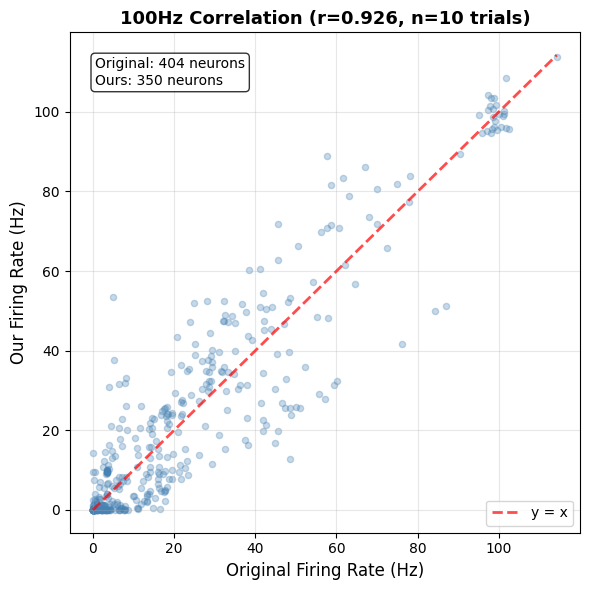

  ✅ Saved: fig1_correlation_100Hz.png
  Correlation: r = 0.9263


In [22]:
if has_original:
    print("\nFigure 1: Correlation with original paper (100Hz)")
    
    fig1, ax1, r_val = plot_correlation(
        rate_orig, rate_ours, 
        n_trials_ours=10, 
        freq=100,
        # save_path = FIGURES_DIR / 'fig1_correlation_100Hz.png'
    )
    
    plt.show()
    print(f"  ✅ Saved: fig1_correlation_100Hz.png")
    print(f"  Correlation: r = {r_val:.4f}")

### 9.2 Response heatmap (Figure 1d style)


Figure 2: Response heatmap (all frequencies)


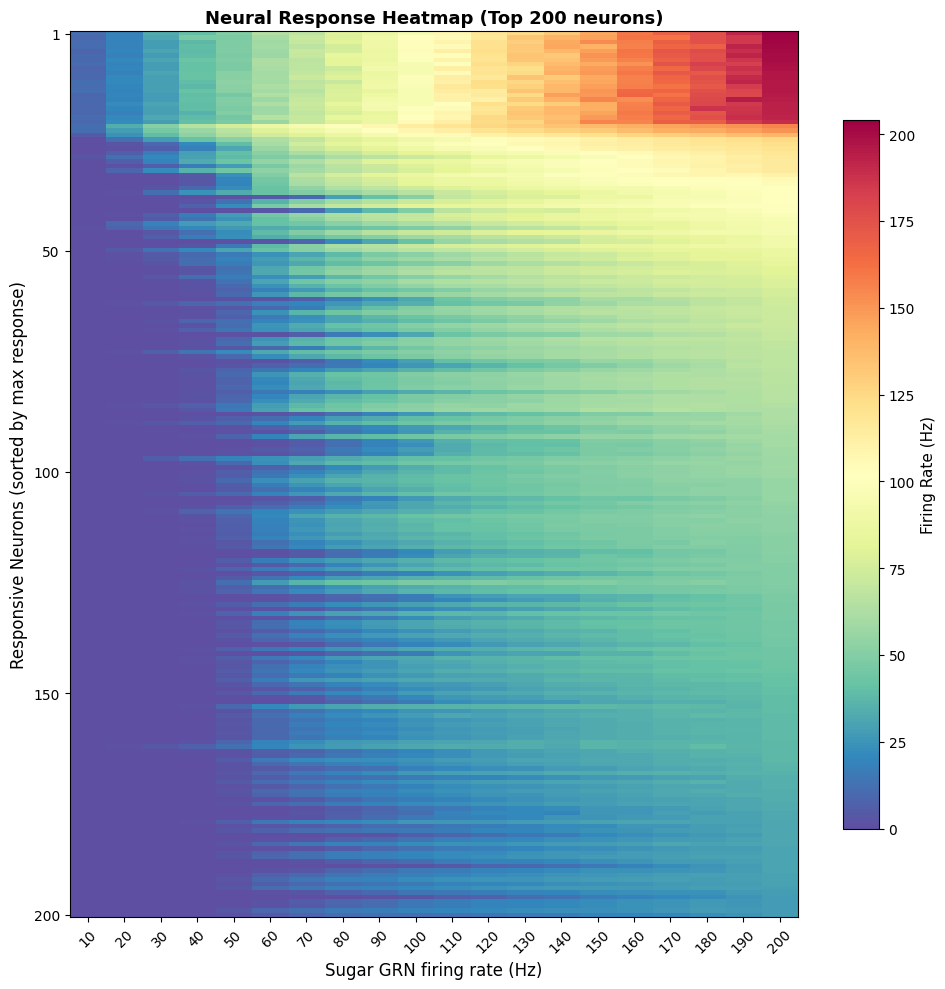

  ✅ Saved: fig2_response_heatmap.png
  Showing top 200 neurons


In [23]:
print("\nFigure 2: Response heatmap (all frequencies)")

fig2, ax2, top_neurons = plot_response_heatmap(
    all_firing_rates, 
    freq_list=sorted(results_dict.keys()),
    cmap=sns.color_palette("Spectral_r", as_cmap=True),
    top_n=None,  # Auto-detect
    preset='auto',
    # save_path = FIGURES_DIR / 'fig2_response_heatmap.png'
)

plt.show()

print(f"  ✅ Saved: fig2_response_heatmap.png")
print(f"  Showing top {len(top_neurons)} neurons")

### 9.3 Proboscis motor neuron responses


Figure 3: MN9 bilateral response curve


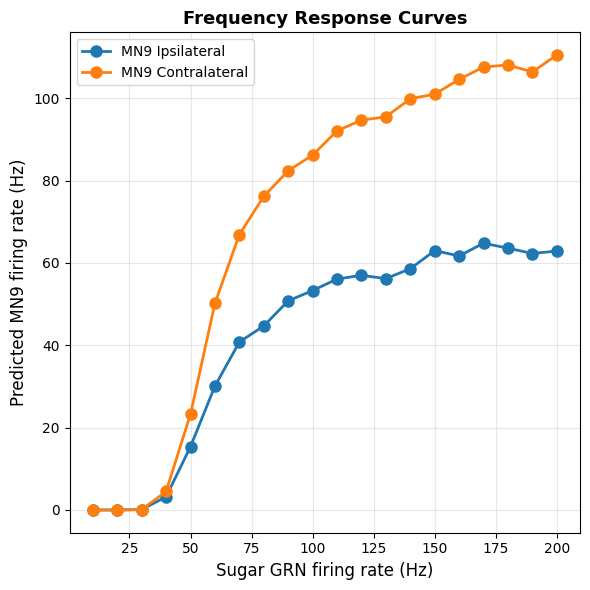

  ✅ Saved: fig3_mn9_bilateral_response.png


In [24]:
# MN9 bilateral (ipsi vs contra)
if NEU_MN9_RIGHT and NEU_MN9_LEFT:
    print("\nFigure 3: MN9 bilateral response curve")
    
    target_neurons = NEU_MN9_LEFT + NEU_MN9_RIGHT
    labels = ['MN9 Ipsilateral', 'MN9 Contralateral']
    
    fig3, ax3 = plot_frequency_response_curve(
        all_firing_rates,
        figsize=(6, 6),
        freq_list=sorted(results_dict.keys()),
        target_neurons=target_neurons,
        labels=labels,
        # save_path = FIGURES_DIR/ 'fig3_mn9_bilateral_response.png'
    )
    
    plt.show()
    print(f"  ✅ Saved: fig3_mn9_bilateral_response.png")
else:
    print("\n⚠️  MN9 IDs not defined, skipping MN9 curve")


Additional Figure: Other proboscis motor neurons


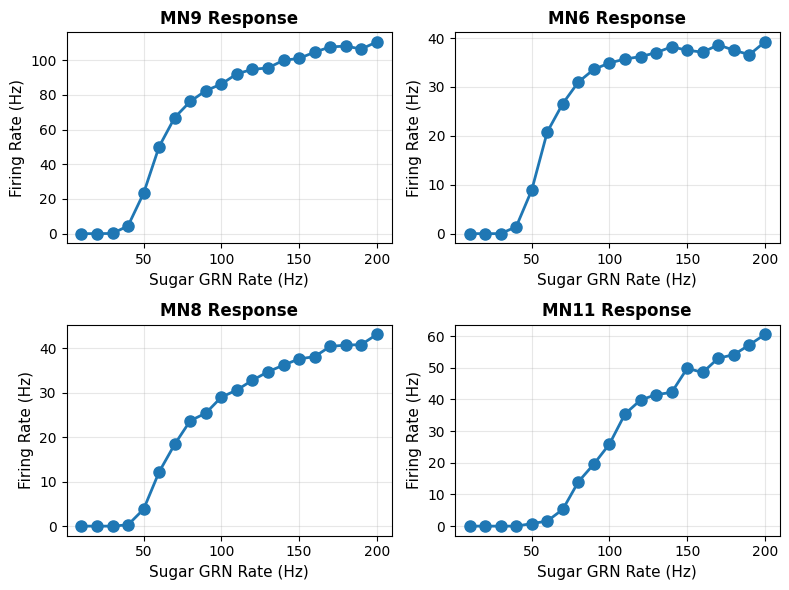

  ✅ Saved: fig_motor_neurons_panel.png


In [25]:
# Additional motor neurons (MN6, 8, 11)
print("\nAdditional Figure: Other proboscis motor neurons")

MN6_RIGHT = 720575940628826128
MN8_RIGHT = 720575940612888178
MN11_RIGHT = 720575940619048827

[MN6_ID, MN8_ID, MN11_ID] = convert_neuron_list_cached(
    old_list=[MN6_RIGHT,MN8_RIGHT,MN11_RIGHT],
    cache_file=CACHE_DIR / 'mn6811_v630_to_v783.pkl',
    new_ver=783,
    verbose=False,)

if all(x is not None for x in [MN6_ID, MN8_ID, MN11_ID]):
    fig, axes = plt.subplots(2, 2, figsize=(8, 6))
    axes = axes.flatten()
    
    mn_ids = [NEU_MN9_RIGHT[0], MN6_ID, MN8_ID, MN11_ID]
    mn_names = ['MN9', 'MN6', 'MN8', 'MN11']
    
    for ax, mn_id, name in zip(axes, mn_ids, mn_names):
        rates = [all_firing_rates[f].get(mn_id, 0) for f in sorted(all_firing_rates.keys())]
        ax.plot(sorted(all_firing_rates.keys()), rates, 'o-', linewidth=2, markersize=8)
        ax.set_xlabel('Sugar GRN Rate (Hz)', fontsize=11)
        ax.set_ylabel('Firing Rate (Hz)', fontsize=11)
        ax.set_title(f'{name} Response', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    # plt.savefig(FIGURES_DIR / 'fig_motor_neurons_panel.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"  ✅ Saved: fig_motor_neurons_panel.png")
else:
    print(f"  ⚠️  Other MN IDs not available, extracting from data...")

### 9.4 Shuffled Connectivity Validation


Figure 4: Shuffled connectivity control


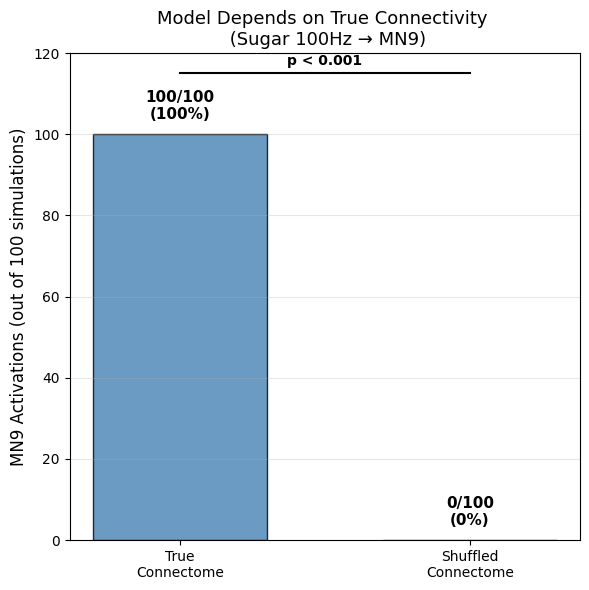

  ✅ Saved: fig5_shuffled_control.png
  Statistical test: Fisher's exact, p = 2.21e-59


In [8]:
# ========== Section 11.5: Shuffled Connectivity Validation ==========

print("\nFigure 4: Shuffled connectivity control")

# Load results (in case kernel restarted)
shuffle_file = SHUFFLE_RESULTS_FILE = RESULTS_DIR / 'shuffled_connectivity_results.pkl' 

if shuffle_file.exists():
    with open(shuffle_file, 'rb') as f:
        shuffle_data = pickle.load(f)
    
    normal_act = shuffle_data['normal_activations']
    shuffled_act = shuffle_data['shuffled_activations']
    
    # Plot
    fig, ax = plt.subplots(figsize=(6, 6))
    
    bars = ax.bar(['True\nConnectome', 'Shuffled\nConnectome'],
                  [normal_act, shuffled_act],
                  color=['steelblue', 'coral'], 
                  edgecolor='black', alpha=0.8, width=0.6)
    
    ax.set_ylabel('MN9 Activations (out of 100 simulations)', fontsize=12)
    ax.set_title('Model Depends on True Connectivity \n (Sugar 100Hz → MN9)', 
                 fontsize=13)
    ax.set_ylim(0, 120)
    
    # Value labels
    for bar, val in zip(bars, [normal_act, shuffled_act]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                f'{val}/100\n({100*val/100:.0f}%)', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Statistical annotation
    from scipy.stats import fisher_exact
    contingency = [[normal_act, 100-normal_act],
                   [shuffled_act, 100-shuffled_act]]
    _, p_value = fisher_exact(contingency)
    
    y_max = max(normal_act, shuffled_act)
    ax.plot([0, 1], [y_max+15, y_max+15], 'k-', linewidth=1.5)
    ax.text(0.5, y_max+17, f'p < 0.001' if p_value < 0.001 else f'p = {p_value:.3f}',
            ha='center', fontsize=10, fontweight='bold')
    
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'fig5_shuffled_control.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"  ✅ Saved: fig5_shuffled_control.png")
    print(f"  Statistical test: Fisher's exact, p = {p_value:.2e}")

else:
    print(f"  ⚠️  Shuffled results not found: {shuffle_file}")
    print(f"     Run Section 10.5 first")

### 9.5 Summary statistics


Figure 5: Summary statistics


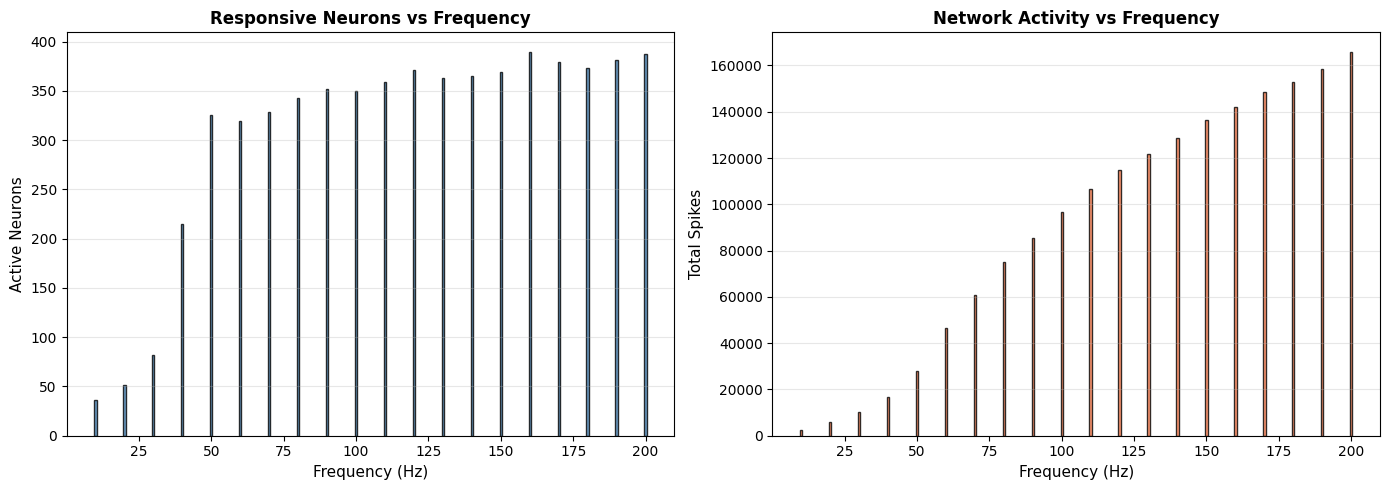

  ✅ Saved: fig4_summary_stats.png

✅ All figures saved to: /Users/ruiluo/MyLibrary/connectome/LIFmodel/LIF_simulation/results/exp1_sugar_activation/figures


In [27]:
print("\nFigure 5: Summary statistics")

fig4, axes4 = plot_summary_statistics(
    df_summary,
    # save_path=FIGURES_DIR / 'fig4_summary_stats.png'
)

plt.show()
print(f"  ✅ Saved: fig4_summary_stats.png")

print(f"\n✅ All figures saved to: {FIGURES_DIR}")

## 10. Generate Top 200 Neurons

In [28]:
print("\n" + "=" * 70)
print("Selecting Top 200 Responsive Neurons")
print("=" * 70)

# Sort by 200Hz firing rate (matching original paper)
if 200 in all_firing_rates:
    rates_200hz = pd.Series(all_firing_rates[200])
    top_200_neurons = rates_200hz.sort_values(ascending=False).head(200).index.tolist()
    
    print(f"\nTop 200 neurons (by 200Hz response):")
    print(f"  Count: {len(top_200_neurons)}")
    print(f"  Min rate: {rates_200hz[top_200_neurons[-1]]:.2f} Hz")
    print(f"  Max rate: {rates_200hz[top_200_neurons[0]]:.2f} Hz")
    
    # Save for Exp2/3
    np.save(RESULTS_DIR / 'top_200_neurons.npy', top_200_neurons)

    # Save as text (readable)
    with open(RESULTS_DIR / 'top_200_neurons.txt', 'w') as f:
        f.write("# Top 200 neurons by 200Hz firing rate\n")
        f.write("# Generated from Exp1 for use in Exp2/Exp3\n")
        f.write(f"# Date: {pd.Timestamp.now()}\n")
        f.write("#\n")
        for i, nid in enumerate(top_200_neurons, 1):
            f.write(f"{i:3d}. {nid} ({rates_200hz[nid]:.2f} Hz)\n")
    
    print(f"\n✅ Saved:")
    print(f"  - {RESULTS_DIR / 'top_200_neurons.npy'}")
    print(f"  - {RESULTS_DIR / 'top_200_neurons.txt'}")
    
    # Show examples
    print(f"\n  Top 10 neurons:")
    for i in range(10):
        nid = top_200_neurons[i]
        rate = rates_200hz[nid]
        print(f"    {i+1:2d}. {nid}: {rate:.1f} Hz")
    
else:
    print("\n❌ No 200Hz data, cannot select Top 200")
    print("   Check if Batch 4 completed successfully")


Selecting Top 200 Responsive Neurons

Top 200 neurons (by 200Hz response):
  Count: 200
  Min rate: 27.30 Hz
  Max rate: 204.10 Hz

✅ Saved:
  - /Users/ruiluo/MyLibrary/connectome/LIFmodel/LIF_simulation/results/exp1_sugar_activation/top_200_neurons.npy
  - /Users/ruiluo/MyLibrary/connectome/LIFmodel/LIF_simulation/results/exp1_sugar_activation/top_200_neurons.txt

  Top 10 neurons:
     1. 720575940639259967: 204.1 Hz
     2. 720575940611875570: 203.3 Hz
     3. 720575940617000768: 202.1 Hz
     4. 720575940612670570: 201.5 Hz
     5. 720575940628853239: 200.7 Hz
     6. 720575940638202345: 200.0 Hz
     7. 720575940637568838: 200.0 Hz
     8. 720575940632425919: 199.3 Hz
     9. 720575940632889389: 197.8 Hz
    10. 720575940621754367: 196.9 Hz


## 11. Save Complete Results

In [29]:
print("\n" + "=" * 70)
print("Saving Complete Results Package")
print("=" * 70)

# Compile complete results package
results_package = {
    'results_dict': results_dict,
    'all_firing_rates': all_firing_rates,
    'df_summary': df_summary,
    'parameters': {
        'freq_list': sorted(results_dict.keys()),
        'n_trials': 10,
        'n_frequencies': len(results_dict),
        'neurons_activated': len(NEU_SUGAR_LEFT),
        'sugar_grn_ids': NEU_SUGAR_LEFT,
        'mn9_ids': {'left': NEU_MN9_LEFT, 'right': NEU_MN9_RIGHT},
    },
    'validation': {
        'correlation_100Hz': r if has_original else None,
        'top_neurons': top_200_neurons if 'top_200_neurons' in dir() else None,
        'original_comparison': df_compare.to_dict() if has_original else None,
    },
    'metadata': {
        'date': pd.Timestamp.now().isoformat(),
        'connectome_version': 783,
        'data_size_mb': DATA['df_conn'].memory_usage(deep=True).sum()/1e6,
    }
}

# Save complete package
with open(RESULTS_DIR / 'exp1_complete_results.pkl', 'wb') as f:
    pickle.dump(results_package, f)
    
print(f"\n✅ Complete results saved:")
print(f"  {RESULTS_DIR / 'exp1_complete_results.pkl'}")

# Save summary CSV
df_summary.to_csv(RESULTS_DIR / 'summary.csv', index=False)
print(f"  {RESULTS_DIR / 'summary.csv'}")

# Save firing rate matrix (neurons × frequencies)
if all_firing_rates:
    all_freqs = sorted(results_dict.keys())
    all_neurons = set()
    for rates_dict in all_firing_rates.values():
        all_neurons.update(rates_dict.keys())
    
    rate_matrix = pd.DataFrame(index=sorted(all_neurons), columns=all_freqs)
    for freq in all_freqs:
        for neuron_id, rate in all_firing_rates[freq].items():
            rate_matrix.loc[neuron_id, freq] = rate
    
    rate_matrix = rate_matrix.infer_objects(copy=False).fillna(0)
    rate_matrix.to_csv(RESULTS_DIR / 'firing_rate_matrix.csv')
    print(f"  {RESULTS_DIR / 'firing_rate_matrix.csv'}")
    print(f"    ({rate_matrix.shape[0]} neurons × {rate_matrix.shape[1]} frequencies)")


Saving Complete Results Package

✅ Complete results saved:
  /Users/ruiluo/MyLibrary/connectome/LIFmodel/LIF_simulation/results/exp1_sugar_activation/exp1_complete_results.pkl
  /Users/ruiluo/MyLibrary/connectome/LIFmodel/LIF_simulation/results/exp1_sugar_activation/summary.csv
  /Users/ruiluo/MyLibrary/connectome/LIFmodel/LIF_simulation/results/exp1_sugar_activation/firing_rate_matrix.csv
    (466 neurons × 20 frequencies)


## 12. Experiment Summary

In [ ]:
print("\n" + "=" * 70)
print("✅ Experiment 1 Complete!")
print("=" * 70)

print(f"\n[Key Results]")
print(f"  Frequencies tested: {len(results_dict)}")
if 'all_neurons' in dir():
    print(f"  Total active neurons: {len(all_neurons)}")
if has_original:
    print(f"  Correlation with paper: r = {r:.4f}")
if 'top_200_neurons' in dir():
    print(f"  Top 200 neurons saved: ✅")

print(f"\n[Outputs]")
print(f"  Results directory: {RESULTS_DIR}")
print(f"  - exp1_complete_results.pkl")
print(f"  - top_200_neurons.npy (for Exp2/3)")
print(f"  - summary.csv (table)")
print(f"  - firing_rate_matrix.csv (neurons × frequencies)")
print(f"  - figures/ (4 plots)")

print(f"\n[Next Steps]")
print(f"  1. Use top_200_neurons.npy in Exp2 (sufficiency test)")
print(f"  2. Use top_200_neurons.npy in Exp3 (necessity test)")
print(f"  3. Compare results with original paper figures")

print("\n" + "=" * 70)

---

## Appendix: Detailed Statistics

In [ ]:
# Detailed summary table
print("\nDetailed Summary (all frequencies):")
print("=" * 70)
print(df_summary.to_string(index=False))

# Firing rate statistics per frequency
print(f"\n\nFiring Rate Distribution per Frequency:")
print("=" * 70)

for freq in sorted(all_firing_rates.keys()):
    rates = list(all_firing_rates[freq].values())
    if rates:
        print(f"\n{freq:3d} Hz:")
        print(f"  Active neurons: {len(rates)}")
        print(f"  Mean rate: {np.mean(rates):.2f} Hz")
        print(f"  Median rate: {np.median(rates):.2f} Hz")
        print(f"  Max rate: {np.max(rates):.2f} Hz")
        print(f"  Std: {np.std(rates):.2f} Hz")

In [ ]:
# Check if specific neurons of interest are in top 200
if 'top_200_neurons' in dir() and NEU_MN9_RIGHT:
    print(f"\n\nNeurons of Interest in Top 200:")
    print("=" * 70)
    
    # MN9
    for mn9_id, side in [(NEU_MN9_LEFT[0], 'Left'), (NEU_MN9_RIGHT[0], 'Right')]:
        if mn9_id in top_200_neurons:
            rank = top_200_neurons.index(mn9_id) + 1
            rate = rates_200hz[mn9_id]
            print(f"  MN9 {side}: Rank {rank}/200 ({rate:.1f} Hz)")
        else:
            print(f"  MN9 {side}: Not in top 200")